# **MEASURING CLASSIFIER PERFORMANCE**

## **For two-class problems**

Let us say we have a **two-class problem**:
* $\omega_1$ (the *positives*)
* $\omega_2$ (the *negatives*).

So, there are four cases:
| Example type | Prediction | Name |
|-----------|-----------|-----------|
| Positive (+)    | Positive (+)   | **True positive (TP)**   |
| Positive (+)    | Negative (-)   | **False positive (FP)**  |
| Negative (-)    | Negative (-)   | **True negative (TN)**   |
| Negative (-)    | Positive (+)   | **False negative (FN)**  |


>  **Type I error**: The **error probability** of the **false positive $Pr(FP)$**, is denoted by $\alpha$
>  * In which case the **probability** of the **true positive** is $1-\alpha$.

> **Type II error:** The **error probability** of a **false negative $Pr(FN)$**,  is denoted by $\beta$
> * And the **probability** of a **true negative** is $1-\beta$.

A **confusion matrix** is a table that illustrates how well a classifier predicts.

<table border="1" style="border-collapse: collapse; text-align: center;">
   <caption style="font-weight: bold; margin-bottom: 10px;"> <b>Confusion Matrix for the two-class problem.</b></caption>
  <tr>
    <th rowspan="2">True Class</th>
    <th colspan="2">Predicted Class</th>
    <th rowspan="2">Total</th>
  </tr>
  <tr>
    <th>Positive</th>
    <th>Negative</th>
  </tr>
  <tr>
    <td><b>Positive</b></td>
    <td>tp : true positive</td>
    <td>fn : false negative</td>
    <td>p</td>
  </tr>
  <tr>
    <td><b>Negative</b></td>
    <td>fp : false positive</td>
    <td>tn : true negative</td>
    <td>n</td>
  </tr>
  <tr>
    <td><b>Total</b></td>
    <td>p'</td>
    <td>n'</td>
    <td>N</td>
  </tr>
</table>

Where $p$ and $n$ represent the total number of positive and negative **examples**. While $p^{'}$ and $n^{'}$ represent the total number of positive or negative **predictions**, respectively.

**Main performance measures**

> **Total Error**
$$e = \frac{fp+fn}{N}=\alpha + \beta$$

> **Accuracy (*exactitud*)**, measures the **proportion** of **correct predictions** in relation to the total number of elements.
$$\frac{tp+tn}{N} = 1- e$$

> **Recall** or **Sensitivity** (**True positive rate, $tp$-rate**), measures what proportion of valid users (positive pattern) we authenticate. Intuitively, it is the **ability** of the classifier to **find all the positive samples**.
$$ \frac{tp}{p}=1-\alpha$$

> **Precision** measures the proportion of records classified as positive that actually are. Intuitively, precision is the **ability** to the classifier **not to label as positive** a sample that is **negative**.
$$\frac{tp}{p'} = \frac{tp}{tp+fp}$$


**Other performance measures**

> **Specificity** is how well we detect the negatives.
$$\frac{tn}{n} = 1 - fp\text{-rate}$$


> **False Positive rate** (**$fp$-rate**) is the proportion of impostors we wrongly accept.
$$\frac{fp}{n}=\alpha$$


## **For $K$-classes problem with $K>2$**

In the case of $K>2$ classes, the **class confusion matrix** $A$ is a $K\times K$ matrix whose entry $A(i, j)$ contains the number of instances that **belong to** class $C_i$  but are **assigned to** class $C_j$.


- Usually organized as **actual rows** versus **predicted columns**.

- The class confusion matrix allows us to **identify** what **types of misclassifications** occur, namely, if there are two classes that are frequently confused.

- Let $n_i$ be the number of elements in the class $C_i$ (sum by rows):
$$n_i = \sum_{l=1}^K A(i,l)$$

- Let $\hat{n}_j$ the number of instances assigned to class $C_j$ by the classifier (sum by columns):
$$\hat{n}_j= \sum_{l=1}^K A(l,j)$$


From the **confusion matrix**, one can directly extract the **recall** and **precision** values for each class, along with the overall accuracy:

> **Overall Accuracy** $Ac$, is the **percentage** of data that has been **correctly classified**. Given a $K$-class problem, $Ac$ is computed form the **diagonal** of the confusion matrix:
$$Ac = \frac{1}{N}\sum_{i=1}^K A(i,i)*100$$


> **Recall** or **Sensitivity** $R_i$, is the **proportion** of data points with true class label $i$, which were **correctly classified** in that class.
$$R_i = R(C_i)= \frac{A(i,i)}{n_i}$$
> - That is, the value of the diagonal $i$ divided by the sum of the row $i$.
> - The **recall** is intuitively the ability of the classifier **to find all the  true samples** of class $i$.
> - Question it answers: *Out of all true samples of class $i$, **how many are detected?***

> **Precision** $P_i$ is the **proportion** of data points **classified as class $i$**, whose **true class label** is indeed $i$.
$$P_i = P(C_i) =\frac{A(i,i)}{\hat{n}_i}$$
> -  That is, the value of the diagonal $i$ divided by the sum of the column $i$.
> - The **precision** is intuitively the ability of the classifier to **correctly label** as class $i$ **only those samples that truly belong** to class $i$.
> - Question it answers: *Out of all samples predicted as class $i$, **how many are truly class $i$?***



> **Balanced accuracy** $BA$, is defined as the **average of recall** obtained on each class.
$$BA = \frac{1}{K} \sum_{i=1}^{K} \frac{A(i,i)}{n_i} $$
> - $BA$ avoids inflated performance estimates on **imbalanced** datasets.
> - It is equivalent to the **Accuracy** with **class-balanced** sample weights.


> **$F_1$-Score**, also known as **balanced $F$-score**, can be interpreted as a **harmonic mean** of the precision and recall.
$$ F_1(C_i) = 2\frac{P_i R_i}{P_i+R_i}$$
>  - An $F_1$-score reaches its **best value** at **1** and worst score at 0.
> - The relative contribution of precision and recall to the F1-score are equal.

> **$F_{\beta}$-Score** is the **weighted harmonic mean** of precision and recall, with precision's contribution to the mean weighted by some parameter $\beta\geq 0$
$$F_{\beta}(C_i) = (1+\beta^2) \frac{P_i R_i}{\beta^2 P_i + R_i}$$
> - $\beta > 1$ gives more weight to recall.
> - $\beta < 1$ favors precision.
> - Asymptotically, $\beta \rightarrow \infty$ consider only recall, and $\beta \rightarrow 0$ only precision.

# **Implementation**

**Scikit-learn** (**sklearn**) is a free and open-source **machine learning library** for the Python programming language.

- It is designed to operate with the Python numerical and scientific libraries **NumPy** and **SciPy**.
- Later that year, Matthieu Brucher started working on this project as part of his thesis.
- Originally, it was a [**Google Summer of Code project**](https://summerofcode.withgoogle.com/) by French Data scientist David Couperneau.
- In 2010, the first public version of the library by a research group of the French Institute for Research in Computer Science and Automation (INRIA).
- **Scikit-learn** is a **community project**, developed by a large group of people, all across the world.

**Sklearn** include modules for:
- **Classification**.
- **Regression**.
- **Clustering**.
- **Dimensionality reduction**.
- **Model selection**.
- **Preprocessing**.

It also includes **metrics and scoring** submodule to evaluate supervised learning models. To import it we use the following code:

In [2]:
from sklearn import metrics

### **Averaging**

In **sklearn**, when there are more than two classes, metrics such as precision, recall, and $F_1$-score are first **computed per class**, and then **aggregated** using the `average` parameter. This parameter specifies how per-class metrics are combined into a single score.

If `average=None`, the metric is returned for each class separately. Otherwise, one of the following averaging strategies is applied.

> `binary`
> - Not valid for multiclass problems.

> `macro`
> - Computes the metric independently for each class and then takes the **unweighted mean**.
> $$ macro = \frac{1}{k} \sum_{i=1}^k M_i$$
where $M_i$ is the corresponding metric of the class $i$.
> - All classes **contribute equally**, regardless of their size.
> - Does not account for **class imbalance**.
> - Useful when performance on minority classes is as important as on majority classes.

> `weighted`
> - Computes the metric for each class and takes the **average weighted** by class support.
> $$ weighted = \sum_{i=1}^k\frac{n_i}{N}  M_i$$
where $M_i$ is the corresponding metric of the class $i$.
> - All classes **contribute equally**, regardless of their size.
> - Accounts for **class imbalance**.
> - Larger classes have more influence.

> `micro`
> - Computes metrics globally by summing true positives, false positives, and false negatives over all classes.
> $$ micro = \frac{\sum_{i=1}^k TP_i}{\sum_{i=1}^k TP_i + FP_i}$$
where $M_i$ is the corresponding metric of the class $i$.
> - Treats the multiclass problem as a single global binary task.
> - Dominated by frequent classes.

# **Example**

We use the iris dataset and the perceptron dataset to show how to use the different metric functions in sklearn.

In [3]:
# Import libraries
import matplotlib.pyplot as plt
from sklearn.svm import LinearSVC
from sklearn.inspection import DecisionBoundaryDisplay
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix, classification_report
from matplotlib.colors import ListedColormap

In [4]:
# Import dataset
from sklearn.datasets import load_iris
X = load_iris()["data"][:130,0:2]
y_true = load_iris()["target"][:130]

In [5]:
# Create and apply the classifier
clf = LinearSVC(max_iter=5)
clf.fit(X, y_true)
y_pred = clf.predict(X)

/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


/tmp/ipython-input-1494447525.py:12: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  display.ax_.scatter([], [], c=cmap(i), label=i)


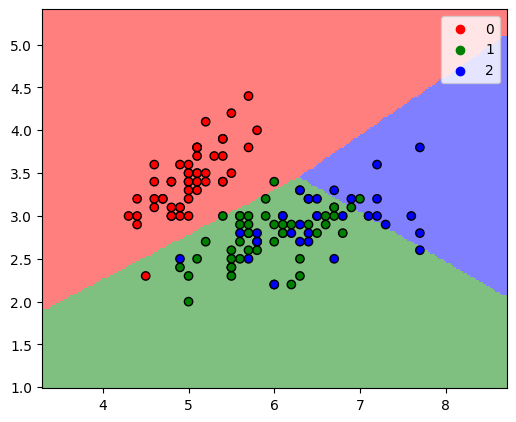

In [6]:
# Display the decision boundaries of the classifier
cmap = ListedColormap(['red', 'green', 'blue'])
fig, ax = plt.subplots(figsize=(6, 6))
display = DecisionBoundaryDisplay.from_estimator(clf, X,
                                                 response_method="predict",
                                                 alpha=0.5, ax=ax,
                                                 grid_resolution=200,
                                                 plot_method="pcolormesh",
                                                cmap=cmap)
display.ax_.scatter(X[:, 0], X[:, 1], c=y_true, edgecolor="k", cmap=cmap)
for i in range(3):
    display.ax_.scatter([], [], c=cmap(i), label=i)
ax.legend()
ax.set_aspect("equal")
plt.show()

### **Confusion matrix**

In [7]:
# Create the confusion matrix
cm = confusion_matrix(y_true, y_pred)
cm

array([[49,  1,  0],
       [ 2, 47,  1],
       [ 0, 20, 10]])

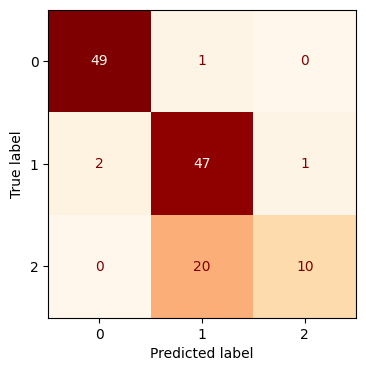

In [8]:
# Display the confusion matrix
fig, ax = plt.subplots(figsize=(4, 4))
disp = ConfusionMatrixDisplay.from_estimator(clf, X, y_true,
                                             cmap = "OrRd",
                                             ax=ax, colorbar=False)
plt.show()

### **Metrics**

In [9]:
# Accuracy
metrics.accuracy_score(y_true, y_pred)

0.8153846153846154

In [10]:
# Balanced accuracy
metrics.balanced_accuracy_score(y_true, y_pred)

np.float64(0.7511111111111112)

In [11]:
# Precision
metrics.precision_score(y_true, y_pred,
                        average=None)

array([0.96078431, 0.69117647, 0.90909091])

In [12]:
# Recall
metrics.recall_score(y_true, y_pred,
                     average=None)

array([0.98      , 0.94      , 0.33333333])

In [14]:
# Recall
metrics.recall_score(y_true, y_pred,
                     average="macro")

0.7511111111111112

In [ ]:
# F1-score
metrics.f1_score(y_true, y_pred,
                 average=None)

In [ ]:
#F-beta score
beta_1 = metrics.fbeta_score(y_true, y_pred,
                    average=None,
                    beta=1)
beta_2 = metrics.fbeta_score(y_true, y_pred,
                    average=None,
                    beta=.1)
print("beta=1", beta_1)
print("beta=2", beta_2)

### **Classification report**

In [ ]:
# Display classification report
report = classification_report(y_true, y_pred)
print(report)

# **References**

- Alpaydin, E. (2010) **Introduction to Machine Learning**, 2nd ed., The MIT Press.

- Dougherty, G. (2013) **Pattern Recognition and Classification. An Introduction**, Springer.

- Theodoridis, S. \& Koutroumbas, K. (2009) **Pattern Recognition**, 4th ed., Academic Press.